In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red"><b>ch4.머신러닝 모형 최적화 </b></font>

# 1절 . 변수 선택과 차원 축소

## 1-1 변수선택과 차원축소
- 종속변수에 영향을 주는 변수들을 찾아 학습에 사용할 독립변수의 수를 줄임
(어 떻 게 하면 score 를 높일 수 있을지)
- 과적합과 변수들 사이의 다중공선성 변수들간 강한 상관관계 을 줄일 수 있음
    * 회귀계수 해석이 어려 워 짐 . 모델 예측력이 좋아도 해석력이 떨어짐 어떤 변수가 제일 큰 요인인지 잘 ), 
    p 값이나 유의성 검정이 왜곡 될 수 있음
- 모형의 학습 시간을 줄일 수 있음
- 주성분분석 , 상관분석 , 분류모형의 feature_importance _, 예측 모형의 coef
- SelectKBest : 가장 높은 score 에 따라 K 개의 특징을 선택

## 1-2 주성분분석 (PCA, Principal Component Anaysis
- 주성분분석은 변수 선택 및 차원축소 방법 기존의 모든 변수를 조합하여 새로운 변수로 만 듦 ) 으로 널리 사용
- 주성분 분석은 상관관계가 있는 변수들을 선형결합해서 분산이 극대화된 상관관계가 없는 새로운 변수 주성분
  들로 축약 하는 것
- 주성분 분석은 사실 선형대수학이라기보다는 선형대수학의 활용적인 측면이 강하며 영상인식 , 
  통계 데이터분석 (주성분 찾기), 데이터 압축 , 노이즈제거 등 여러 분야에 사용
- 영상처리에서 많이 활용 : 여러개의 영상 중 대표 이미지를 찾을 때 활용

In [3]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X,iris_y = iris.iloc[:,:-1],iris.iloc[:,-1]
iris_X.shape,iris_y.shape

((150, 4), (150,))

In [5]:
# 다중공전성이 있는 독립변수 4개를 다중공전성전혀 없는 새로운 독립변수2개로
pca = PCA(n_components=2)
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [6]:
import pandas as pd
df = pd.DataFrame(iris_pca, columns=['pca1','pca2'])
df.corr()

,pca1,pca2
pca1,1.000000e+00,1.407550e-15
pca2,1.407550e-15,1.000000e+00


In [9]:
# iris_X => df
pd.concat([iris_X, df], axis=1)


,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,-2.728717,0.326755
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532
146,6.3,2.5,5.0,1.9,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,1.900942,0.116628


In [10]:
# 설명분산 : 각 주성분이 원 데이터 정보량을 얼마나 잘표현하는지 : 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [11]:
pca.explained_variance_ratio_ 
# 0~1사이의 비율로 조정된 설명분산
# 2개의 주성분으로 전체 데이터(독립변수4)의 97.77% 정도 설명

array([0.92461872, 0.05306648])

In [12]:
pca.components_ # 주성분의 계수 : 각 주성분이 원래 특성들과 어떤 관계가 있는지의 가중치
# pca1 = 0.36138659*x0 -0.08452251*x1 + 0.85667061*x2 + 0.3582892*x3
# pca2 = 0.65658877*x0 + 0.73016143*x1 - 0.17337266*x2 - 0.07548102*x3

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1-3 상관관계 확인

- 타겟변수와 상관관계가 높은 독립변수들만 선택

In [13]:
# redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.sample()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
219,7.8,0.53,0.33,2.4,0.08,24.0,144.0,0.99655,3.3,0.6,9.5,5


- cmap의 종류 : https://jrc-park.tistory.com/155
- http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap
- http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (20,4)

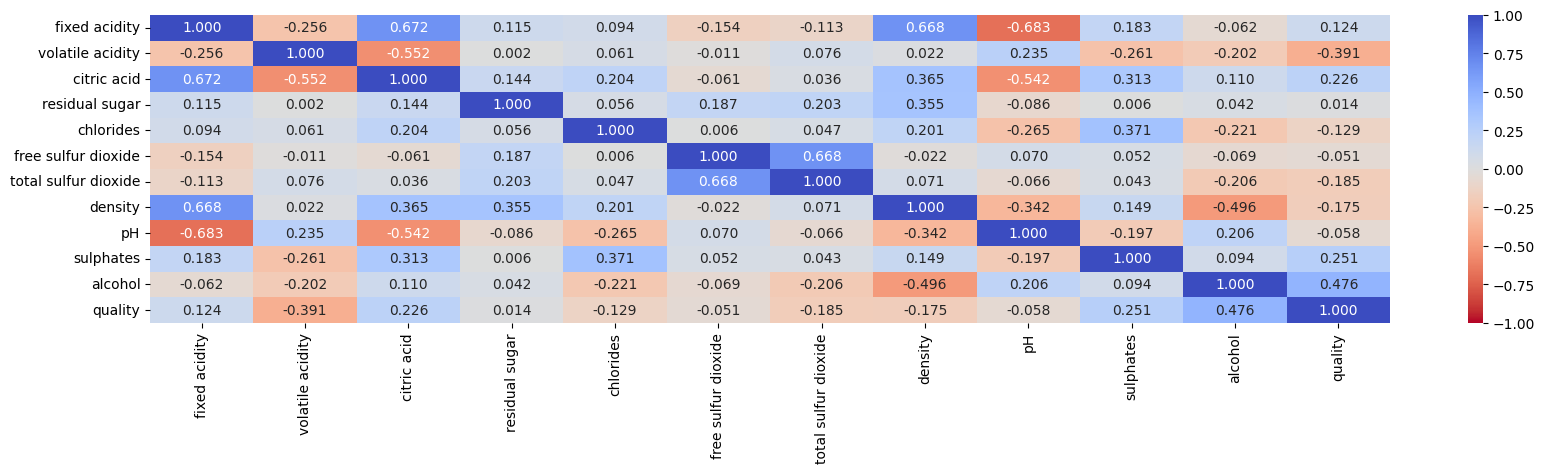

In [14]:
corr = redwine.corr()
#corr
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r')
plt.show()

In [15]:
mask = np.tril(np.ones_like(corr), k=0) # 대각선 포함 아래가 1인 삼각행렬(기본값0)
mask


array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

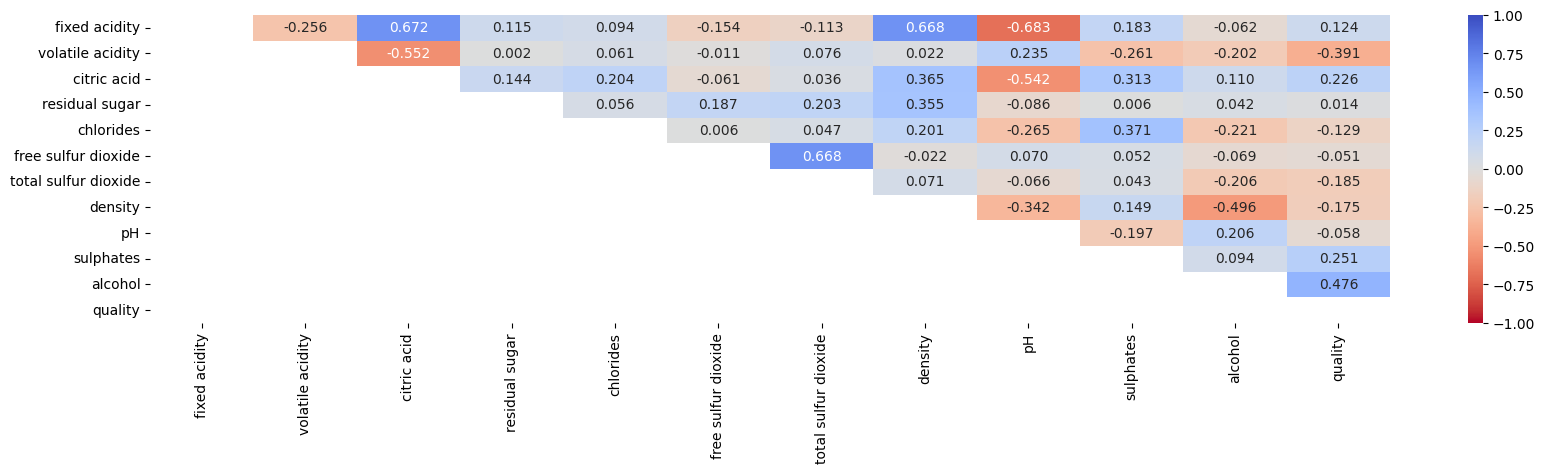

In [16]:
sns.heatmap(corr, annot=True, fmt='.3f', vmin=-1, vmax=1, cmap='coolwarm_r', mask=mask)
plt.show()

## 1-4 분류모형의 feature_importance_
- 모형의 feature_importance_ 속성은 독립변수들이 종속변수에 영향을 주는 정도를 저장
- DecisionTreeClassifier, RandomForestClassifier(tree계열), GradientBoostingClassifier, XGBclassifier, LGBMclassifier, CatBoostClassifier
- LogisticRegression이나 SVC, MLPclassifier, MultinomialNB등은 feature_importance_없음

In [17]:
X = redwine.iloc[:, :-1].to_numpy()
y = redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y) # 층화추출
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10,
                                 random_state=10)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [19]:
features = pd.DataFrame(np.c_[redwine.columns[:-1],
                            rf_model.feature_importances_],
                       columns=['feature', 'importance'])
features['importance'].sum()

0.9999999999999998

In [20]:
features.sort_values(by='importance', ascending=False, inplace=True)
features

,feature,importance
10,alcohol,0.161593
9,sulphates,0.105586
1,volatile acidity,0.098732
6,total sulfur dioxide,0.098514
4,chlorides,0.084197
3,residual sugar,0.082538
8,pH,0.080177
0,fixed acidity,0.076785
2,citric acid,0.074787
7,density,0.070725


### feature_importance_를 이용한 변수 중요도 시각화

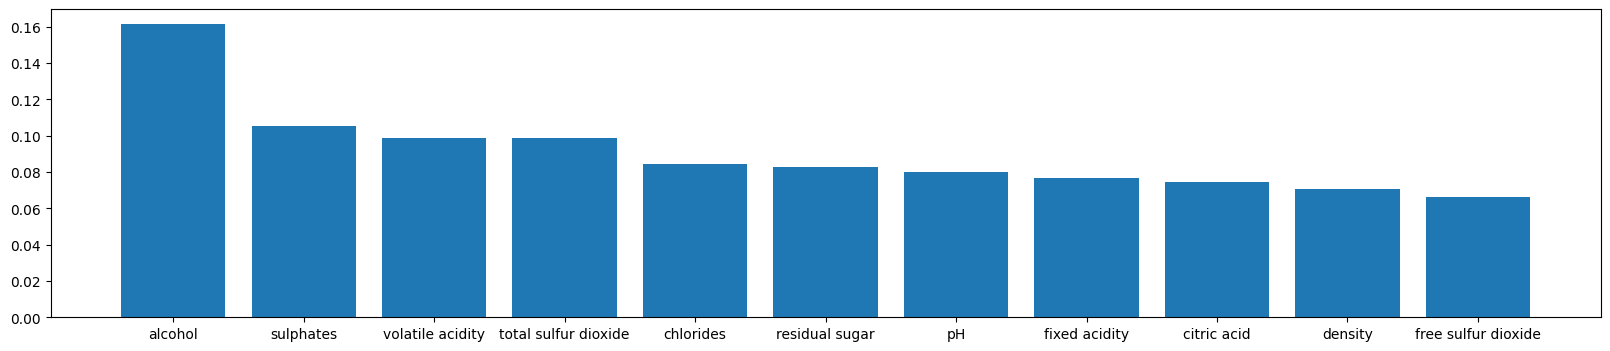

In [21]:
plt.bar(features.feature, features.importance)
plt.show()

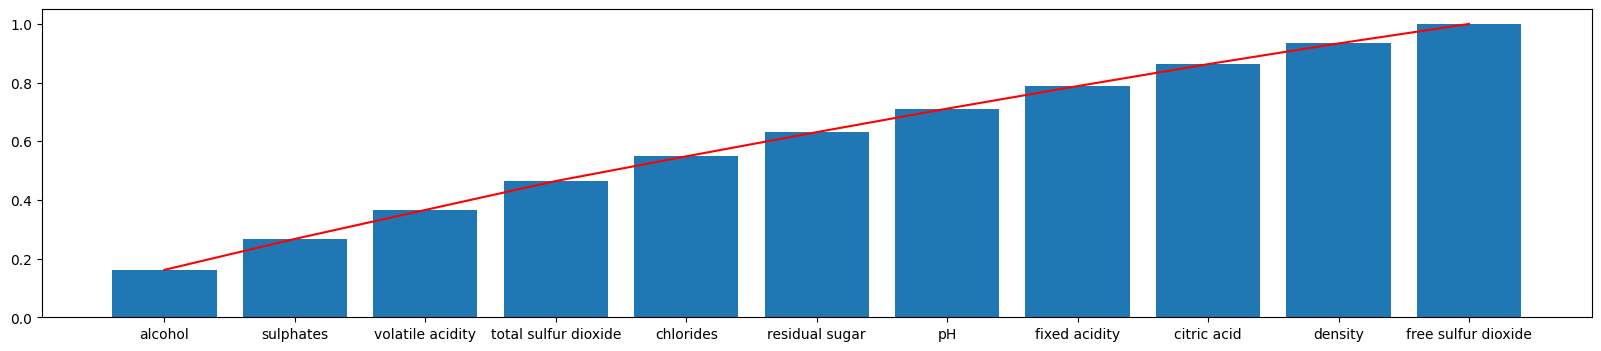

In [22]:
# 누적합을 이용한 시각화
y_stack = np.cumsum(features.importance) # importance 누적
# y_stack 
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.show()

### RFE(Recursive Feature Elimination) 방식
- 중요도에 따라 낮은 변수부터 하나씩 제거해 나가면서 최종적으로 선택하고자 하는 변수의 갯수만큼 남긴다

In [23]:
# 5개의 특징이 남을 때까지 변수를 제거(기준 : feature_importance_)
from sklearn.feature_selection import RFE
rfe_model = RFE(#RandomForestClassifier(n_estimators=10,random_state=10)
    rf_model,
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)
# rfe_model.get_support()
features_rfe = pd.DataFrame(np.c_[redwine.columns[:-1],
                                 rfe_model.get_support()],
                           columns=['feature', 'selected'])
features_rfe.sort_values(by='selected', ascending=False)

,feature,selected
1,volatile acidity,True
6,total sulfur dioxide,True
7,density,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
4,chlorides,False
5,free sulfur dioxide,False


In [4]:
from sklearn.datasets import load_iris
X,y=load_iris(return_X_y=True)
X.shape, y.shape,type(X)

((150, 4), (150,), numpy.ndarray)

In [6]:
from sklearn.feature_selection import SelectKBest,f_classif
X_new = SelectKBest(score_func=f_classif,
                   k=2).fit_transform(X,y)
X_new[:3]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2]])

# 2절. 파라미터 탐색

- 하이퍼파라미터(사용자가 직접 설정할 수 있는 파라미터). 어떤 파라미터를 넣는게 최적의 결과르르 낼지 탐색
    * validation_curve() : 단일 하이퍼파라미터 최적화 함수(한개의 파라미터 찾아줌)
    * GridSearchCV : 그리드를 이용한 복수 하이퍼 파라미터 최적화 클래스(가장 높은 score를 내는 모형를 찾아줌)
    
## 2-1 단일 파라미터 탐색과 모형 최적화
    * validation_curve() : 최적화할 파라미터 이름과 범위, 성능 측적 기준을 매개변수로 받아, 파라미터의 모든 범위의 성능을 계산

In [9]:
# 데이터
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
images = digits.images
X.shape, y.shape, images.shape


((1797, 64), (1797,), (1797, 8, 8))

In [10]:
import numpy as np
np.all(X[0].reshape(8,8) == images[0]) # 행렬의 모든 item에 True인지 여부

True

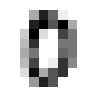

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1,1))
plt.imshow(images[0], cmap='gray_r')
plt.axis('off')
plt.show()

In [12]:
# SVC 모델 생성
from sklearn.svm import SVC
model = SVC(probability=True)
model.fit(X, y)

SVC(probability=True)

In [13]:
model.score(X, y)

0.996661101836394

In [14]:
h = model.predict(X[0].reshape(1, -1))[0]
prob = model.predict_proba(X[0].reshape(1, -1))[0]
model.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [15]:
print(f'예측 : {h}')
for c, p in zip(model.classes_, prob):
    print(f'{c}일 확률 : {p:.2%}')

예측 : 0
0일 확률 : 99.11%
1일 확률 : 0.02%
2일 확률 : 0.05%
3일 확률 : 0.09%
4일 확률 : 0.06%
5일 확률 : 0.14%
6일 확률 : 0.07%
7일 확률 : 0.09%
8일 확률 : 0.08%
9일 확률 : 0.29%


In [16]:
print(model.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [17]:
# 탐색할 gamma의 범위
param_range = np.linspace(0.00001,0.1,10)
param_range

array([1.000e-05, 1.112e-02, 2.223e-02, 3.334e-02, 4.445e-02, 5.556e-02,
       6.667e-02, 7.778e-02, 8.889e-02, 1.000e-01])

In [20]:
%%time
from sklearn.svm import SVC
from sklearn.model_selection import validation_curve
train_score, test_score = validation_curve(
                        SVC(), # 예측모형
                        X, y, # 데이터
                        param_name='gamma', # gamma가 크면 결정경계 복잡
                        param_range=param_range,
                        cv=10, # 교차검증 10개로 나눠 1개는 test셋, 9개는 train
                        scoring='accuracy', # 모형평가 기준(precision, recall, f1, roc_auc, ...)
                        n_jobs=-1   # 사용할 core 갯수(-1은 모든 core를 다 씀)
                      )

CPU times: total: 484 ms
Wall time: 13.1 s


In [21]:
test_score.shape, train_score.shape

((10, 10), (10, 10))

In [22]:
# 행별 평균
train_scores_mean = np.mean(train_score, axis=1)
train_scores_std  = np.std(train_score, axis=1)
test_scores_mean = np.mean(test_score, axis=1)
test_scores_std  = np.std(test_score, axis=1)

In [23]:
test_scores_std

array([0.03984436, 0.05948282, 0.05253688, 0.04667371, 0.02522211,
       0.01664422, 0.00786961, 0.01192294, 0.00730563, 0.00764792])

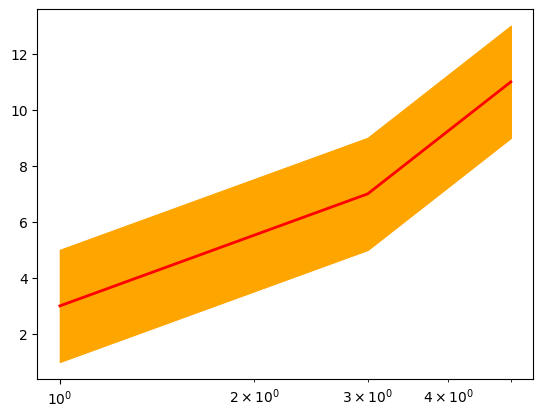

In [24]:
a = np.array([1,3,5])
b = np.array([3,7,11])
plt.semilogx(a,b,c='r',lw=2)
plt.fill_between(a,b-2,b+2,color='orange')
plt.show()

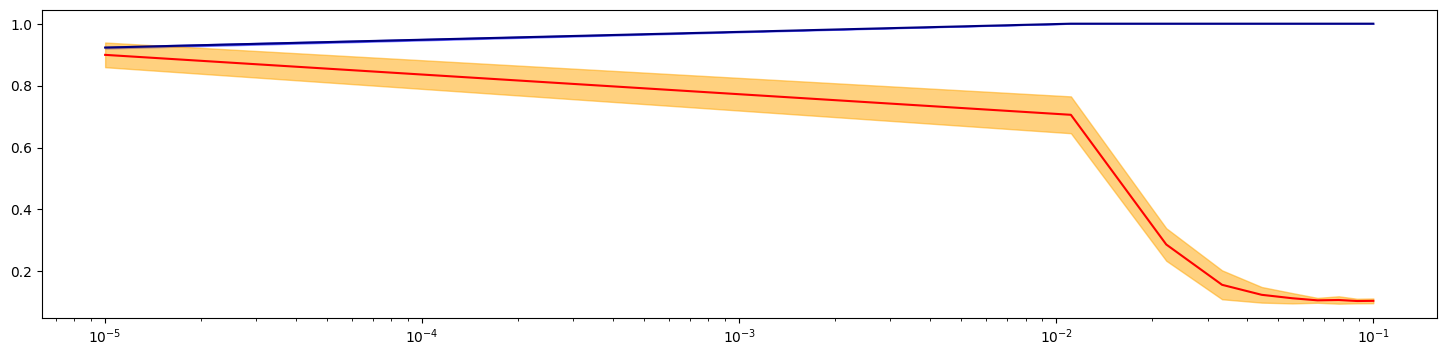

In [31]:
plt.figure(figsize=(18,4))
plt.semilogx(param_range, train_scores_mean, label='train score', color='navy')
plt.fill_between(param_range,
                train_scores_mean-train_scores_std,
                train_scores_mean+train_scores_std,
                color='blue', alpha=0.5)
plt.semilogx(param_range, test_scores_mean, label='test score', color='red')
plt.fill_between(param_range,
                test_scores_mean-test_scores_std,
                test_scores_mean+test_scores_std,
                color='orange', alpha=0.5)

In [33]:
test_scores_mean.argmax() # 최적의 gamma값이 있는 index

0

In [34]:
gamma = param_range[test_scores_mean.argmax()]
gamma

1e-05

In [35]:
model = SVC(gamma=gamma).fit(X, y)
model.score(X, y)

0.9271007234279355

## 2-2 GridSearchCV
- 복수 하이퍼 파라미터 최적화 클래스
- 모형 래퍼 성격 클래스(가장 좋은 모형을 가지고 있음)
- fit(), predict(), score(), predict_proba(), decition_function() 메소드 가능

In [32]:
import pandas as pd
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine_X, redwine_y = redwine.iloc[:,:-1],redwine.iloc[:,-1]
redwine_X.shape,redwine_y.shape

((1599, 11), (1599,))

In [36]:
%%time
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
selection = SelectKBest(k=1) # 가장 Anova f검정의 score가 높은 k개 변수를 찾음
svc       = SVC()
pipeline = Pipeline([('select', selection),
                     ('svc',    svc)])
# param_grid = {'select__k':[4,5,6,7,8,9,10,11],
#               'svc__C':[0.1, 1, 10], # 값이 클수록 오차허용이 엄격
#               'svc__gamma':[0.001, 0.002]
#              }
param_grid = dict(select__k=[4,5,6,7,8,9,10,11],
                  svc__C = [0.1, 1, 10],
                  svc__gamma = [0.001, 0.002])
grid_search = GridSearchCV(pipeline,
                          param_grid=param_grid, # 파라미터들
                          cv=2, # 2fold 교차검증
                          verbose=1,
                          n_jobs=-1 # 모든 코어를 다 씀 
                          )
grid_search.fit(redwine_X, redwine_y)

Fitting 2 folds for each of 48 candidates, totalling 96 fits
CPU times: total: 438 ms
Wall time: 4.05 s


GridSearchCV(cv=2,
             estimator=Pipeline(steps=[('select', SelectKBest(k=1)),
                                       ('svc', SVC())]),
             n_jobs=-1,
             param_grid={'select__k': [4, 5, 6, 7, 8, 9, 10, 11],
                         'svc__C': [0.1, 1, 10], 'svc__gamma': [0.001, 0.002]},
             verbose=1)

In [37]:
# 최적의 파라미터값과 selectKBest의 k값
print(grid_search.best_estimator_)

Pipeline(steps=[('select', SelectKBest(k=11)), ('svc', SVC(C=10, gamma=0.002))])


In [38]:
# 최적의 파라미터값과 selectKBest의 k값
print(grid_search.best_params_)

{'select__k': 11, 'svc__C': 10, 'svc__gamma': 0.002}


In [39]:
model = grid_search.best_estimator_
model.score(redwine_X, redwine_y)

0.6035021888680425

In [40]:
# 학습데이터가 넘파이면 predict도 넘파이로, 학습데이터 데이터프레임이면 predict도 데이터프레임으로(경고출력X)
# x_data = redwine_X.iloc[0].values.reshape(1, -1)
x_data = pd.DataFrame(redwine_X.iloc[0]).T 
model.predict(x_data)

array([5], dtype=int64)

# 3절. 자료불균형 처리



## 3-1 SMOTE를 이용한 오버샘플링 전

In [43]:
# 데이터 
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=10000, # 표본 데이터수
                        n_features=10,   # 독립변수갯수
                        n_informative=5, # 종속변수와 상관관계가 있는 독립변수
                        n_classes=2,     # 종속변수의 클래스
                        n_clusters_per_class=1, # 클래스당 군의 수
                        weights=[0.99,0.01], # 각클래스의 할당된 표본 비율 
                        random_state=42
                       )
X.shape,y.shape

((10000, 10), (10000,))

In [44]:
import numpy as np
np.unique(y, return_counts=True)

(array([0, 1]), array([9850,  150], dtype=int64))

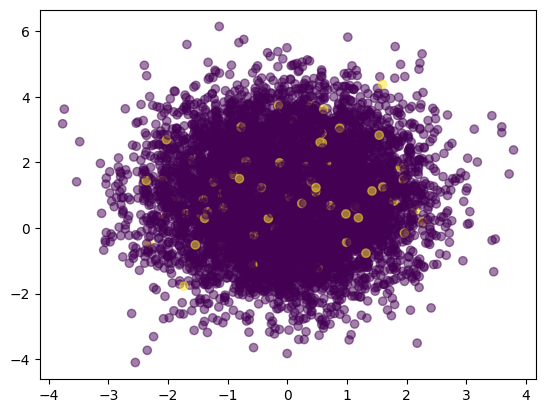

In [45]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], y=X[:, 1], c=y, alpha=0.5)

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y, # 층화추출
                                                   random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

In [47]:
print(np.unique(y, return_counts=True))
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([9850,  150], dtype=int64))
(array([0, 1]), array([6895,  105], dtype=int64))
(array([0, 1]), array([2955,   45], dtype=int64))


In [48]:
y.mean(), y_train.mean(), y_test.mean()

(0.015, 0.015, 0.015)

In [49]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, # 모델에서 사용할 트리 갯수
                                 max_features=2, # 각 노드에서 분할에 사용할 특징(열)의 최대수
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_features=2, random_state=42)

In [50]:
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, rf_pred)


array([[2955,    0],
       [  35,   10]], dtype=int64)

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



## 3-2 SMOTE를 이용한 오버샘플링 후

- pip install imbalanced-learn=0.10.1

In [53]:
X_train.shape,y_train.shape, X_test.shape, y_test.shape

((7000, 10), (7000,), (3000, 10), (3000,))

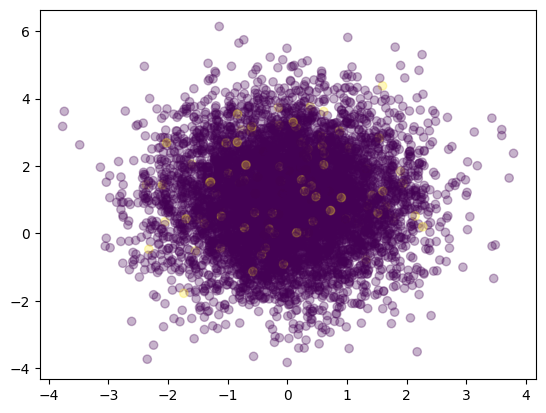

In [54]:
plt.scatter(x=X_train[:, 0], y=X_train[:,1], c=y_train, alpha=0.3)
plt.show()

In [55]:
np.unique(y_train, return_counts=True), y_train.shape

((array([0, 1]), array([6895,  105], dtype=int64)), (7000,))

In [56]:
# SMOTE 오버샘플링(X_train에만 적용)
from imblearn.over_sampling import SMOTE
sm = SMOTE(
        # sampling_strategy={0:6895, 1:1050}
)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)
X_resampled.shape, y_resampled.shape

((13790, 10), (13790,))

In [57]:
np.unique(y_resampled, return_counts=True)

(array([0, 1]), array([6895, 6895], dtype=int64))

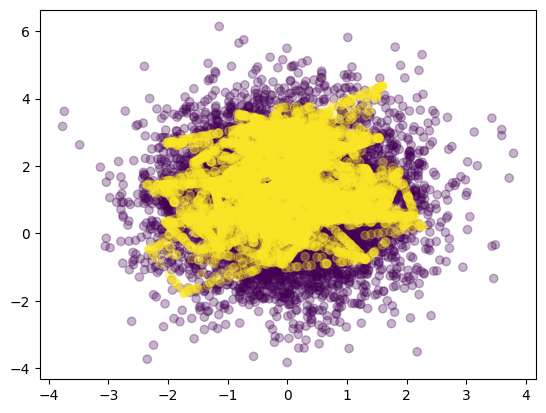

In [58]:
plt.scatter(x=X_resampled[:, 0], y=X_resampled[:,1], c=y_resampled, alpha=0.3)
plt.show()

In [59]:
rf_model = RandomForestClassifier(n_estimators=100,
                                 max_features=2,
                                 random_state=42)
rf_model.fit(X_resampled, y_resampled)

RandomForestClassifier(max_features=2, random_state=42)

In [60]:
rf_pred = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)


array([[2933,   22],
       [  25,   20]], dtype=int64)

In [61]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2955
           1       0.48      0.44      0.46        45

    accuracy                           0.98      3000
   macro avg       0.73      0.72      0.73      3000
weighted avg       0.98      0.98      0.98      3000



## 3-3 가중치 제어
- 예측모형에 class_weight 매개변수 이용

In [62]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2,
                                 class_weight={0:1, 1:2.5}, # y가 1인 데이터는 2.5배 더 중요하게 
                                 random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 1, 1: 2.5}, max_features=2,
                       random_state=42)

In [63]:
rf_pred  = rf_model.predict(X_test)
confusion_matrix(y_test, rf_pred)

array([[2955,    0],
       [  35,   10]], dtype=int64)

In [64]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2955
           1       1.00      0.22      0.36        45

    accuracy                           0.99      3000
   macro avg       0.99      0.61      0.68      3000
weighted avg       0.99      0.99      0.98      3000



# 4절. 최적모형탐색
- 앙상블 모형
    * 목적 : 여러분류모델을 하나의 통합분류 모델로 연결하여 개별분류모델보다 더 좋은 일반화 성능을 달성
    * 방법
        * 여러 분류 알고리즘 사용 : 다수결 투표(Voting)
        * 하나의 분류 알고리즘을 여러개 사용 : 배깅(bagging;병렬), 부스팅(boosting:자료불균형일 경우 조금더 잘 맞는경향)
        

## cf.배깅 알고리즘시

In [65]:
np.random.choice(10,10,replace=True)# 10개 데이터에서 복원추출로 10개를 뽑음

array([6, 9, 0, 7, 5, 2, 8, 3, 3, 3])

In [66]:
N = 10000000 # 63.2% => 부트스트래핑과 0.632규칙
bootstrap = np.random.choice(N, N, replace=True)
print(len(set(bootstrap)), '개')
print(len(set(bootstrap))/N *100 , '%')

6320816 개
63.20816 %


## 4-1. 배깅

In [67]:
import pandas as pd
wine_df = pd.read_csv('data/wine.csv')
wine_df.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,0D280/0D315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [68]:
wine_df['Class label'].value_counts()

2    71
1    59
3    48
Name: Class label, dtype: int64

In [69]:
X = wine_df.iloc[:, 1:]
y = wine_df.iloc[:, 0]
X.shape, y.shape

((178, 13), (178,))

In [70]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.3,
                                                   stratify=y,
                                                   random_state=1)
train_X.shape, test_X.shape

((124, 13), (54, 13))

In [71]:
# 의사결정나무 알고리즘
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(train_X, train_y)
tree.score(test_X, test_y)


0.9074074074074074

In [72]:
%%time
# 배깅 알고리즘
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(estimator=tree,
                       n_estimators=500,
                       bootstrap=True, # 복원추출로 중복추출 허용
                       oob_score=True, # 중복추출로 학습에 빠진 데이터를 score에 적용한 점수 볼 수 있음 
                       random_state=1)
bag.fit(train_X, train_y)
bag.score(test_X, test_y)

CPU times: total: 1.53 s
Wall time: 1.54 s


0.9629629629629629

In [73]:
# 각 모델이 학습할 때 뽑히지 않은 샘플을 이용하여 계산 성능 점수
bag.oob_score_


0.9435483870967742

## 4-2 임의의 데이터를 만들어 최적 모형 탐색

In [74]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=10000,
                          n_features=10,
                          n_informative=5,
                          n_classes=2,
                          n_clusters_per_class=1,
                          weights=[0.9, 0.1],
                          random_state=42)
X.shape, y.shape, np.unique(y, return_counts=True)

((10000, 10), (10000,), (array([0, 1]), array([8963, 1037], dtype=int64)))

In [75]:
train_X, test_X, train_y, test_y = train_test_split(X, y,
                                                   test_size=0.2,
                                                   stratify=y,
                                                   random_state=42)
# train데이터의 오버샘플링
sm = SMOTE()
resampled_X, resampled_y = sm.fit_resample(train_X, train_y)
resampled_X.shape, resampled_y.shape, np.unique(resampled_y, return_counts=True)

((14340, 10), (14340,), (array([0, 1]), array([7170, 7170], dtype=int64)))

In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score
def model_measure(model, train_X=resampled_X, train_y=resampled_y, test_X=test_X, test_y=test_y):
    '매개변수로 모델을 학습한 후, 모델의 정확도, 정밀도, 재현율, f1점수를 return'
    model.fit(train_X, train_y) # 학습
    pred = model.predict(test_X) # 예측값
    accuracy = model.score(test_X, test_y)
    precision = precision_score(test_y, pred)
    recall    = recall_score(test_y, pred)
    f1score   = f1_score(test_y, pred)
    return '정확도:{:.3f}, 정밀도:{:.3f}, 재현율:{:.3f}, f1 socre:{:.3f}'.format(accuracy,
                                                                       precision,
                                                                       recall,
                                                                       f1score)

In [77]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
model_measure(rf_model)

'정확도:0.984, 정밀도:0.944, 재현율:0.894, f1 socre:0.918'

In [83]:
from sklearn.svm import SVC
svc_model = SVC(random_state=42)
model_measure(svc_model)


'정확도:0.988, 정밀도:0.960, 재현율:0.918, f1 socre:0.938'

In [84]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500)
model_measure(mlp_model)

'정확도:0.978, 정밀도:0.889, 재현율:0.894, f1 socre:0.892'

## 4-3 부스팅(AdaBoost, XGB, LGBM, CatB)
- 알고리즘들을 순차적으로 학습하면서 이전 학습한 알고리즘 예측이 틀린 데이터를 올바르게 예측할 수 있도록 가중치 부여

In [85]:
from sklearn.ensemble import AdaBoostClassifier
model_measure(AdaBoostClassifier())

'정확도:0.956, 정밀도:0.732, 재현율:0.908, f1 socre:0.810'

In [86]:
from xgboost import XGBClassifier
model_measure(XGBClassifier(n_estimators=100, max_depth=10))

'정확도:0.984, 정밀도:0.944, 재현율:0.899, f1 socre:0.921'

In [79]:
from lightgbm import LGBMClassifier
# 행 기준으로 각 피처를 빠르게 탐색
model_measure(LGBMClassifier(n_estimators=100, force_row_rise=True, verboss=0))

[LightGBM] [Warning] Unknown parameter: force_row_rise
[LightGBM] [Warning] Unknown parameter: verboss
[LightGBM] [Warning] Unknown parameter: force_row_rise
[LightGBM] [Warning] Unknown parameter: verboss
[LightGBM] [Info] Number of positive: 7170, number of negative: 7170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000958 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2550
[LightGBM] [Info] Number of data points in the train set: 14340, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Unknown parameter: force_row_rise
[LightGBM] [Warning] Unknown parameter: verboss
[LightGBM] [Warning] Unknown parameter: force_row_rise
[LightGBM] [Warning] Unknown parameter: verboss


'정확도:0.985, 정밀도:0.936, 재현율:0.913, f1 socre:0.924'

In [81]:
from catboost import CatBoostClassifier
model_measure(CatBoostClassifier(verbose=0))

'정확도:0.986, 정밀도:0.954, 재현율:0.908, f1 socre:0.931'

## 4-4 투표를 이용한 앙상블
- voting='hard' : 다수결로 투표
- voting='soft' : 확률이 합을 계산하여 투표

In [87]:
rf_model = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42)
xgb_model = XGBClassifier(max_depth=10,
                         n_estimators=100) # 이진분류에서의 평가 지표
lgb_model = LGBMClassifier(n_estimators=100, verbose=0)
svc_model = SVC(probability=True, random_state=42)
print(model_measure(rf_model))
print(model_measure(xgb_model))
print(model_measure(lgb_model))
print(model_measure(svc_model))

정확도:0.984, 정밀도:0.944, 재현율:0.894, f1 socre:0.918
정확도:0.984, 정밀도:0.944, 재현율:0.899, f1 socre:0.921
정확도:0.985, 정밀도:0.936, 재현율:0.913, f1 socre:0.924
정확도:0.988, 정밀도:0.960, 재현율:0.918, f1 socre:0.938


In [88]:
%%time
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm', rf_model),
                                            ('lgb', lgb_model),
                                            ('svc', svc_model)],
                               voting='hard')
voting_model.fit(resampled_X, resampled_y)

CPU times: total: 15.2 s
Wall time: 13.3 s


VotingClassifier(estimators=[('rfm',
                              RandomForestClassifier(max_features=2,
                                                     random_state=42)),
                             ('lgb', LGBMClassifier(verbose=0)),
                             ('svc', SVC(probability=True, random_state=42))])

In [89]:
print(model_measure(voting_model))

정확도:0.986, 정밀도:0.954, 재현율:0.908, f1 socre:0.931


In [90]:
# 개별 모델
voting_model.named_estimators_

{'rfm': RandomForestClassifier(max_features=2, random_state=42),
 'lgb': LGBMClassifier(verbose=0),
 'svc': SVC(probability=True, random_state=42)}

In [91]:
from sklearn.ensemble import VotingClassifier
voting_model = VotingClassifier(estimators=[('rfm', rf_model),
                                            ('lgb', lgb_model),
                                            ('svc', svc_model)],
                               voting='soft')
model_measure(voting_model)

'정확도:0.985, 정밀도:0.931, 재현율:0.918, f1 socre:0.925'